In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Loading and First Look of Data

In [81]:
medical_device = pd.read_csv('medical_device_dataset.csv')
medical_device.head()

,HospitalCode,TypeDescription,Age,ServiceSupport,AssetCondition,ServiceIntention,FrequencyMaintenanceRequirement,MaintenanceComplexity,TotalDowntime,AlternativeBackup,Operations,MaintenanceCost,Make,Model,Manufacturer,Brand,PurchaseDate,MonthsToFailure,FailureClass
0,PRK350,Ventilator,23,1,0,3,1,1,48.77,1,2,24464.07,USA,Carestation 650 #986,Datex-Ohmeda Inc,Carestation,2018-03-13,4.0,2
1,PRK300,Infusion Pump,20,1,0,2,1,1,0.00,1,2,0.00,Germany,Infusomat Space #805,B. Braun Melsungen AG,Infusomat,2017-06-12,NaN,1
2,PRK350,Defibrillator,1,0,0,3,1,1,0.00,1,2,0.00,USA,Lifepak 20e #757,Physio-Control Inc,Lifepak,2001-08-04,NaN,1
3,PRK333,Physiologic Monitoring System,9,0,0,1,1,1,115.87,1,2,7187.28,Japan,Life Scope #806,Nihon Kohden Corp,Nihon Kohden,2004-08-20,37.0,2
4,PRK340,Infusion Pump,18,1,0,2,1,1,11.80,0,2,33213.29,USA,Sigma Spectrum #710,Baxter Healthcare Corp,Sigma,2013-07-08,21.0,2


In [82]:
medical_device.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   HospitalCode                     5000 non-null   str    
 1   TypeDescription                  5000 non-null   str    
 2   Age                              5000 non-null   int64  
 3   ServiceSupport                   5000 non-null   int64  
 4   AssetCondition                   5000 non-null   int64  
 5   ServiceIntention                 5000 non-null   int64  
 6   FrequencyMaintenanceRequirement  5000 non-null   int64  
 7   MaintenanceComplexity            5000 non-null   int64  
 8   TotalDowntime                    5000 non-null   float64
 9   AlternativeBackup                5000 non-null   int64  
 10  Operations                       5000 non-null   int64  
 11  MaintenanceCost                  5000 non-null   float64
 12  Make                           

In [83]:
medical_device['MonthsToFailure'].value_counts()

MonthsToFailure
12.0    114
10.0    114
9.0     110
14.0    107
11.0    107
13.0     98
22.0     96
20.0     94
25.0     92
23.0     92
19.0     91
8.0      90
7.0      89
15.0     87
28.0     87
21.0     86
18.0     86
17.0     83
26.0     82
16.0     81
29.0     78
31.0     76
27.0     74
37.0     73
38.0     71
36.0     70
6.0      66
30.0     65
34.0     64
35.0     64
40.0     62
24.0     62
5.0      61
43.0     59
33.0     58
42.0     57
44.0     54
32.0     52
39.0     50
4.0      48
41.0     44
45.0     40
47.0     39
2.0      37
3.0      37
49.0     37
46.0     35
48.0     32
50.0     30
53.0     24
55.0     24
51.0     23
52.0     20
54.0     17
56.0     15
58.0      9
57.0      8
59.0      7
60.0      5
Name: count, dtype: int64

In [84]:
medical_device.describe()

,Age,ServiceSupport,AssetCondition,ServiceIntention,FrequencyMaintenanceRequirement,MaintenanceComplexity,TotalDowntime,AlternativeBackup,Operations,MaintenanceCost,MonthsToFailure,FailureClass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5.000000e+03,3633.000000,5000.000000
mean,9.931200,0.674800,0.162000,1.857400,1.105800,1.001200,208.920190,0.24500,1.91980,5.326820e+03,24.715937,1.910600
std,6.694702,0.468496,0.476027,0.652649,0.324079,0.034624,1020.650406,0.43013,0.27163,3.721732e+04,13.883531,0.670446
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,1.00000,0.000000e+00,2.000000,1.000000
25%,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,2.00000,0.000000e+00,13.000000,1.000000
50%,9.000000,1.000000,0.000000,2.000000,1.000000,1.000000,19.590000,0.00000,2.00000,1.271950e+02,23.000000,2.000000
75%,13.000000,1.000000,0.000000,2.000000,1.000000,1.000000,106.325000,0.00000,2.00000,1.358860e+03,35.000000,2.000000
max,30.000000,1.000000,2.000000,3.000000,3.000000,2.000000,25743.000000,1.00000,2.00000,1.368804e+06,60.000000,3.000000


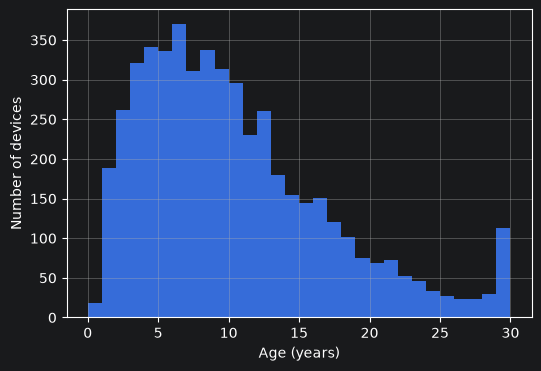

In [85]:
medical_device["Age"].hist(bins=30, figsize=(6, 4))
plt.xlabel("Age (years)")
plt.ylabel("Number of devices")
plt.show()

### Dropping rows which dont have output

In [86]:
# This code will keep only devices which have failure class 2 or 3 as the devices with failure class 1 never failed.
medical_device = medical_device[medical_device["FailureClass"] != 1].copy()
medical_device["FailureClass"].value_counts()

FailureClass
2    2713
3     920
Name: count, dtype: int64

### Splitting Data into Training and Testing Sets

In [87]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    medical_device, test_size=0.2, stratify=medical_device['FailureClass'], random_state=42
) 

### Visualizing Training Data

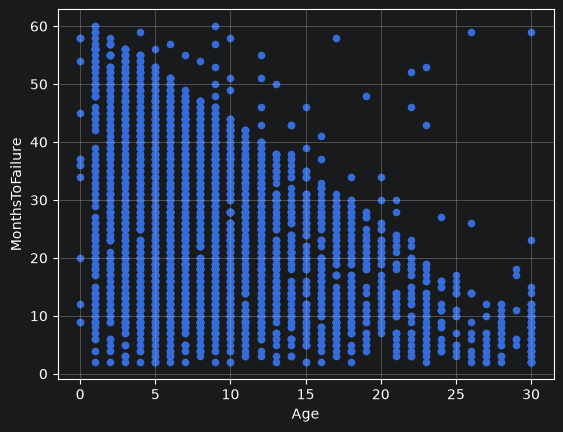

In [88]:
train_set.plot(kind="scatter", x="Age", y="MonthsToFailure", grid=True)
plt.show()

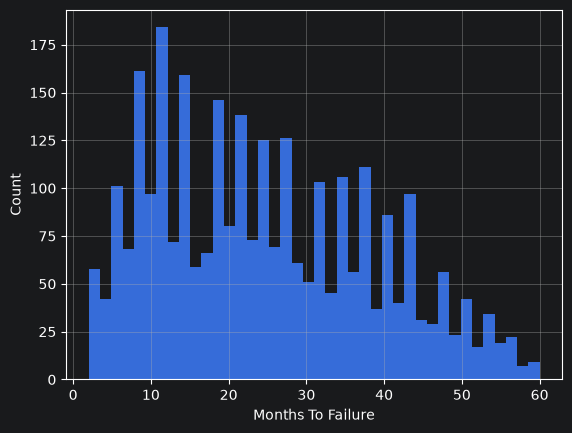

In [89]:
plt.hist(train_set['MonthsToFailure'], bins=40)
plt.xlabel('Months To Failure')
plt.ylabel('Count')
plt.grid(True)
plt.show()

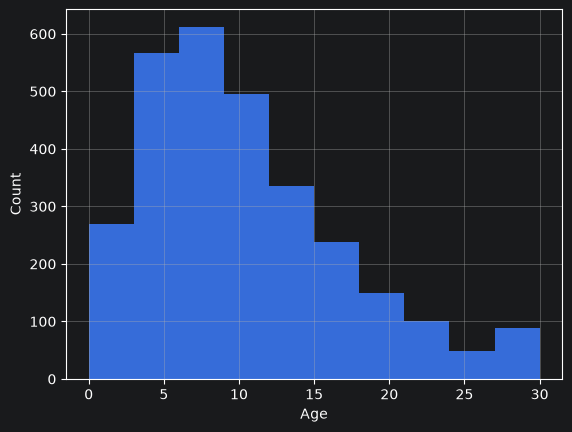

In [90]:
plt.hist(train_set['Age'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

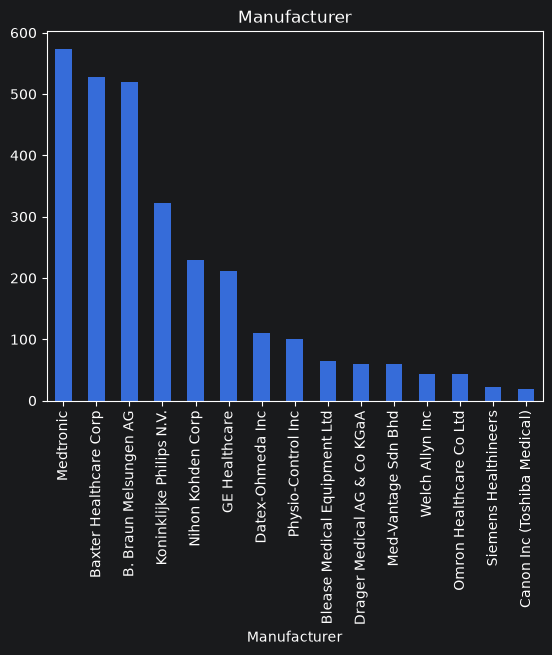

In [91]:
train_set["Manufacturer"].value_counts().plot(kind="bar")
plt.title("Manufacturer")
plt.show()

In [92]:
corr_matrix = train_set[[
    "Age",
    "Operations",
    "ServiceIntention",
    "MaintenanceComplexity",
    "AssetCondition",
    "AlternativeBackup",
    "ServiceSupport",
    "FrequencyMaintenanceRequirement",
    "MaintenanceCost",
    "TotalDowntime", 'MonthsToFailure']].corr()
corr_matrix["MonthsToFailure"].sort_values(ascending=False)

MonthsToFailure                    1.000000
ServiceIntention                   0.033535
MaintenanceComplexity              0.025842
TotalDowntime                      0.019531
AlternativeBackup                  0.012464
FrequencyMaintenanceRequirement    0.009454
MaintenanceCost                   -0.001672
Operations                        -0.011452
ServiceSupport                    -0.123871
AssetCondition                    -0.153272
Age                               -0.415568
Name: MonthsToFailure, dtype: float64

### Feature Comparison

C:\Users\Prerak\AppData\Local\Temp\ipykernel_15572\2897892735.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


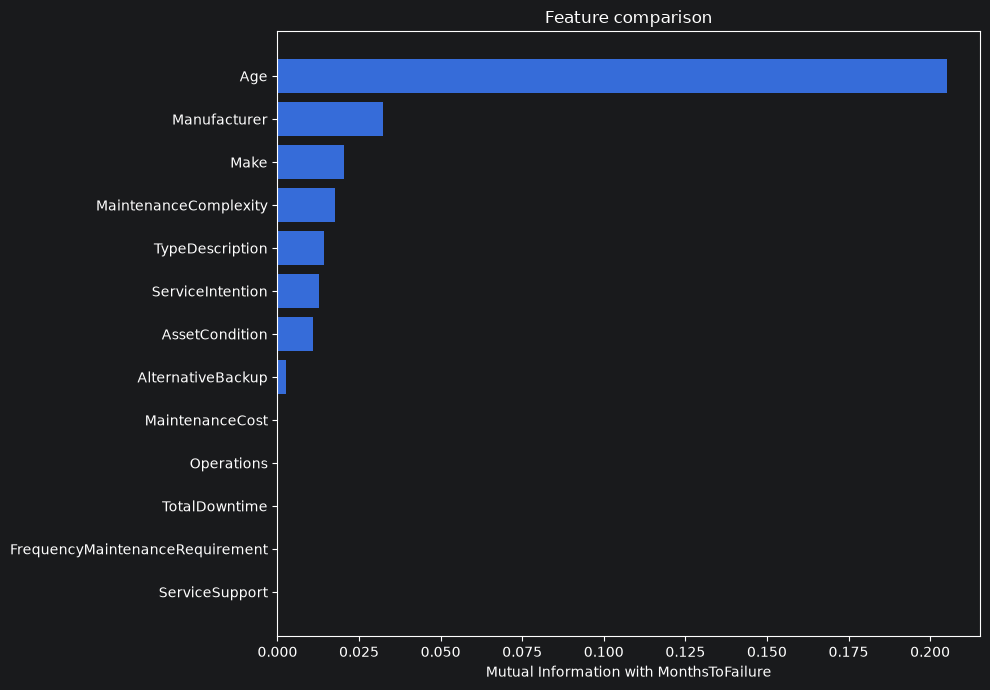

In [114]:
from sklearn.feature_selection import mutual_info_regression

features = ["Age", "ServiceSupport", "AssetCondition", "ServiceIntention",
            "FrequencyMaintenanceRequirement", "MaintenanceComplexity", "TotalDowntime",
            "AlternativeBackup", "Operations", "MaintenanceCost", "Make", "Manufacturer",
            "TypeDescription"]

X = train_set[features].copy()

#Turn text categories into numbers
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category").cat.codes

y = train_set["MonthsToFailure"]

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=features).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(mi_series.index, mi_series.values)
plt.xlabel("Mutual Information with MonthsToFailure")
plt.title("Feature comparison")
plt.tight_layout()
plt.show()

In [116]:
features = ["TypeDescription", "Age", "AssetCondition", "Manufacturer", "Operations","MaintenanceComplexity"]
X_train = train_set[features]
y_train = train_set['MonthsToFailure'].copy()
X_test = test_set[features]
y_test = test_set['MonthsToFailure'].copy()

### Building Transformation Pipline

In [117]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_attribs = ["Age", "AssetCondition", "Operations"]
cat_attribs = ["TypeDescription", "Manufacturer"]

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"),
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

### Selecting different training models

#### Linear Regression

In [118]:
from sklearn.linear_model import LinearRegression

linear_reg = make_pipeline(preprocessing, LinearRegression())
linear_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['TypeDescription','Age','AssetCondition','Manufacturer','Operations', 'MaintenanceComplexity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [119]:
predictions = linear_reg.predict(X_train)
predictions[:5]

array([25.91850396, 28.09987275, 23.41045445, 22.54855628, 25.99614896])

In [120]:
from sklearn.metrics import root_mean_squared_error
linear_reg_rmse = root_mean_squared_error(y_train, predictions)
linear_reg_rmse

12.610009539661796

#### Decision Tree

In [121]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
decision_tree_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['TypeDescription','Age','AssetCondition','Manufacturer','Operations', 'MaintenanceComplexity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

In [122]:
tree_predictions = decision_tree_reg.predict(X_train)
tree_rmse = root_mean_squared_error(y_train, tree_predictions)
tree_rmse

11.33514552288366

#### Random Forest

In [123]:
from sklearn.ensemble import RandomForestRegressor

random_forest_reg = make_pipeline(preprocessing, RandomForestRegressor(n_estimators=100, max_features=8, random_state=42))
random_forest_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['TypeDescription','Age','AssetCondition','Manufacturer','Operations', 'MaintenanceComplexity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatic

In [124]:
forest_predictions = random_forest_reg.predict(X_train)
forest_rmse = root_mean_squared_error(y_train, forest_predictions)
forest_rmse

11.452839196298427

#### XGBoost

In [125]:
from xgboost import XGBRegressor

xgb_reg = make_pipeline(preprocessing, XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
xgb_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['TypeDescription','Age','AssetCondition','Manufacturer','Operations', 'MaintenanceComplexity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pass

In [126]:
xgb_predictions = xgb_reg.predict(X_train)
xgb_rmse = root_mean_squared_error(y_train, xgb_predictions)
xgb_rmse

11.756475817005429

### Final Predictions of all models on test set

In [127]:
# Linear regression
final_predictions = linear_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, final_predictions)
rmse

12.410136795862181

In [128]:
# Decision Tree
final_predictions = decision_tree_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, final_predictions)
rmse

13.73663751761421

In [129]:
# Random Forest
final_predictions = random_forest_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, final_predictions)
rmse

13.228841951434235

In [130]:
# XGBoost
final_predictions = xgb_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, final_predictions)
rmse

12.836518016671576

### Fine Tuning

In [131]:
# XGBoost Fine Tuning

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "xgbregressor__n_estimators": [100, 200, 300, 500],
    "xgbregressor__max_depth": [2, 3, 4, 5],
    "xgbregressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "xgbregressor__subsample": [0.5, 0.6, 0.8, 1.0],
    "xgbregressor__colsample_bytree": [0.6, 0.8, 1.0],
    "xgbregressor__min_child_weight": [1, 5, 10, 20],
    "xgbregressor__reg_alpha": [0, 0.1, 1],
    "xgbregressor__reg_lambda": [1, 5, 10, 15],
}

random_search = RandomizedSearchCV(
    xgb_reg, param_dist, n_iter=40, cv=5,
    scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(-random_search.best_score_)

{'xgbregressor__subsample': 1.0, 'xgbregressor__reg_lambda': 5, 'xgbregressor__reg_alpha': 1, 'xgbregressor__n_estimators': 200, 'xgbregressor__min_child_weight': 20, 'xgbregressor__max_depth': 2, 'xgbregressor__learning_rate': 0.03, 'xgbregressor__colsample_bytree': 0.8}
12.71176304038703


### Final Evaluation on test set

In [132]:
final_model = random_search.best_estimator_

final_predictions = final_model.predict(X_test)
rmse = root_mean_squared_error(y_test, final_predictions)
rmse

12.388452746660548

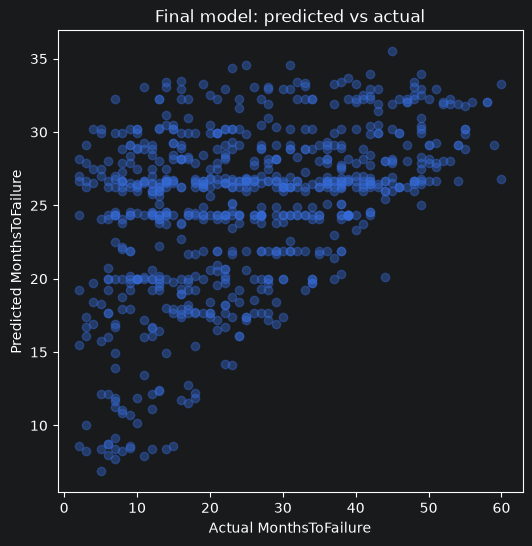

In [133]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_predictions, alpha=0.4)
plt.xlabel("Actual MonthsToFailure")
plt.ylabel("Predicted MonthsToFailure")
plt.title("Final model: predicted vs actual")
plt.show()

In [134]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
)
import numpy as np

# Predictions
final_predictions = final_model.predict(X_test)

# Regression metrics
mae = mean_absolute_error(y_test, final_predictions)
rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
r2 = r2_score(y_test, final_predictions)
median_ae = median_absolute_error(y_test, final_predictions)
explained_var = explained_variance_score(y_test, final_predictions)

print("Model Performance")
print("-----------------")
print(f"MAE                  : {mae:.2f} months")
print(f"RMSE                 : {rmse:.2f} months")
print(f"R² Score             : {r2:.3f}")
print(f"Median Absolute Error: {median_ae:.2f} months")
print(f"Explained Variance   : {explained_var:.3f}")

Model Performance
-----------------
MAE                  : 10.36 months
RMSE                 : 12.39 months
R² Score             : 0.196
Median Absolute Error: 9.75 months
Explained Variance   : 0.196


### Saving Model

In [136]:
import joblib

joblib.dump(final_model, "medical_device_failure_prediction.pkl")

['medical_device_failure_prediction.pkl']